### READ ME
Add the NEWtags.txt file into current working directory for this file for this code to work properly. 


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

#filepath to new tags file
file_path = os.path.join(os.getcwd(), 'NEWtags.txt')


This function is intended to count photons for the specified detectors into discrete time intervals of length dt. It then generates the frequency histogram(s) of photons counts for the of the specified channels

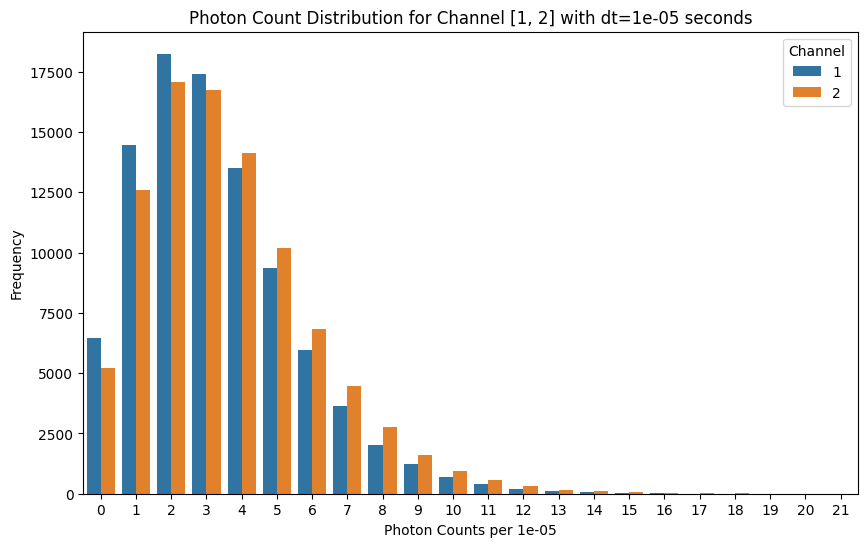

In [12]:
#read in the tags file
tags = pd.read_csv(file_path, delimiter = "\\s+",header=None, names=['Channel', 'Time'])

#function to generate photon count histogram for a given channel and dt
def photon_count(tags,channel = [1], dt=1e-6, fullplot=False):
    '''
    Args: 
        tags: dataframe with detector photon tag files (headers 'Channel' and 'Time')
        channel: list of channels to include in data, e.g. [1,2,3] would include channels 1,2,3 the histogram
        dt: time bin dt in seconds
        fullplot: plot additional histograms for single channels

    Returns:
        Bar plot of photon count distribution for specified channels and dt
    '''
    #convert timestamp to seconds and add a column for time bins
    localtags = tags.copy()
    localtags['Time'] = localtags['Time']*156.25e-12
    localtags['dt'] = localtags['Time']//dt
    #agregate events per channel and time bin
    localtags_grouped = localtags.groupby(['Channel','dt']).size().reset_index(name='Counts')
    localtags_grouped.sort_values(by='dt')
    #reindex to add missing time bins with 0 counts
    all_dt = pd.DataFrame({'dt': np.arange(0, localtags_grouped['dt'].max()+1)})
    all_channels = pd.DataFrame({'Channel': channel})
    all_combinations = all_channels.merge(all_dt, how='cross')
    localtags_grouped = all_combinations.merge(localtags_grouped, on=['Channel','dt'], how='left').fillna(0)
   
    #frequencies of counts by channel
    localtags_freq = localtags_grouped.groupby('Channel')['Counts'].value_counts().reset_index(name='Frequency')

    #frequency histogram of counts by 
    localtags_freq = localtags_freq.sort_values(by='Counts')
    
    localtags_freq = localtags_freq[localtags_freq['Channel'].isin(channel)]
    #data type conversion for plotting
    localtags_freq['Counts'] = localtags_freq['Counts'].astype(int)
    localtags_freq['Frequency'] = localtags_freq['Frequency'].astype(int)
    localtags_freq['Channel'] = localtags_freq['Channel'].astype('category')

    #plotting
    plt.figure(figsize=(10,6))
    sns.barplot(data=localtags_freq, x='Counts', y='Frequency', hue='Channel', dodge=True)
    
    plt.xlabel(f'Photon Counts per {dt}')
    plt.ylabel('Frequency')
    plt.title(f'Photon Count Distribution for Channel {channel} with dt={dt} seconds')
    plt.show()

    if fullplot and len(channel) > 1: 
        #additional plots for single channels
        for ch in channel:
                plt.figure(figsize=(10,6))
                sns.barplot(data=localtags_freq[localtags_freq['Channel']==ch], x='Counts', y='Frequency',color=sns.color_palette()[ch-1])
                plt.xlabel(f'Photon Counts per {dt}')
                plt.ylabel('Frequency')
                plt.title(f'Photon Count Distribution for Channel {ch} with dt={dt} seconds')
                plt.show()


photon_count(tags, channel=[1,2], dt=10e-6, fullplot=False)